## ⚠️ IMPORTANT: Before Running

### Required folder structure in Google Drive:
```
MyDrive/images/
  ├── cassiopeia/
  ├── crux/
  ├── cygnus/
  ├── gemini/
  ├── leo/
  ├── orion/
  └── ursa_major/
```
Access images here: [Constellation Images](https://drive.google.com/drive/folders/1q4SkFq9ItMgH9Xq33CHmbNABI9_7iljr?usp=sharing)

### What changed from the original notebook (conference version):
1. **3-way split** — train / validation / test (70% / 15% / 15%). Test set is held out completely until final evaluation.
2. **Reproducible shuffles** — every `np.random.shuffle` now uses a fixed `RANDOM_SEED` so results are reproducible.
3. **Augmentation-after-split guaranteed** — augmentation is only applied to the training directory, never the test or validation directories.
4. **5-fold stratified cross-validation** — the model is trained 5 times on different folds to get stable mean ± std accuracy.
5. **Multiple seed runs** — after CV, the best architecture is retrained 5 times with different seeds to report variance.
6. **Baseline model** — a simple 3-layer CNN trained from scratch is evaluated alongside MobileNetV2.
7. **Final test set evaluation** — the saved model is evaluated once on the held-out test set. This is the number reported in the paper.
8. **Dataset provenance summary** — a documentation cell records source counts, licenses, and data-cleaning decisions.


## Imports and Environment Setup

In [5]:
import os
import shutil
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from scipy import stats as scipy_stats
from PIL import Image as PILImage
from IPython.display import display
from google.colab import drive

drive.mount('/content/drive')
print(f"TensorFlow Version: {tf.__version__}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow Version: 2.19.0


## Project Configuration

In [6]:
# ── Directory paths ──────────────────────────────────────────
DATA_DIR   = '/content/drive/MyDrive/images'
TRAIN_DIR  = '/content/train'
VAL_DIR    = '/content/validation'
TEST_DIR   = '/content/test'
MODEL_DIR  = '/content/drive/MyDrive/models'

# ── Hyperparameters ───────────────────────────────────────────
IMG_HEIGHT    = 224
IMG_WIDTH     = 224
BATCH_SIZE    = 8
EPOCHS        = 50          # max epochs (EarlyStopping will trigger earlier)
FINE_TUNE_EPOCHS = 20       # extra epochs for optional fine-tuning phase
LEARNING_RATE = 1e-4        # ← lowered from 1e-3: safer for transfer learning heads
FINE_TUNE_LR  = 1e-5        # learning rate for fine-tuning unfrozen layers

# ── Split ratios (must sum to 1.0) ────────────────────────────
TRAIN_SPLIT = 0.70
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15

# ── Reproducibility ───────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# ── Cross-validation / multi-seed settings ────────────────────
N_FOLDS = 5
N_SEEDS = 5

os.makedirs(MODEL_DIR, exist_ok=True)
print("Configuration initialized.")
print(f"  Split  →  train {TRAIN_SPLIT:.0%} | val {VAL_SPLIT:.0%} | test {TEST_SPLIT:.0%}")
print(f"  LR (head)      : {LEARNING_RATE}")
print(f"  LR (fine-tune) : {FINE_TUNE_LR}")
print(f"  Seed: {RANDOM_SEED}  |  CV folds: {N_FOLDS}  |  Multi-seed runs: {N_SEEDS}")


Configuration initialized.
  Split  →  train 70% | val 15% | test 15%
  LR (head)      : 0.0001
  LR (fine-tune) : 1e-05
  Seed: 42  |  CV folds: 5  |  Multi-seed runs: 5


## Utility Functions — Image Preprocessing

In [7]:
def convert_all_images_to_jpg(data_dir):
    """
    Standardizes dataset by converting non-JPG images (WebP, PNG, etc.)
    to JPEG format. Transparency channels are composited onto white background.
    """
    if not os.path.exists(data_dir):
        print(f"Error: Directory not found at {data_dir}")
        return

    total_converted = 0
    folders = [f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))]
    print("Initiating image format conversion...")

    for folder in folders:
        folder_path = os.path.join(data_dir, folder)
        image_files = [f for f in os.listdir(folder_path)
                       if f.lower().endswith(('.webp', '.png', '.bmp', '.gif'))]

        for img_file in image_files:
            try:
                original_path = os.path.join(folder_path, img_file)
                jpg_path = os.path.join(folder_path, img_file.rsplit('.', 1)[0] + '.jpg')
                img = PILImage.open(original_path)

                # Handle transparency channels
                if img.mode in ('RGBA', 'LA', 'P'):
                    background = PILImage.new('RGB', img.size, (255, 255, 255))
                    if img.mode == 'P':
                        img = img.convert('RGBA')
                    background.paste(img, mask=img.split()[-1] if img.mode == 'RGBA' else None)
                    img = background
                elif img.mode != 'RGB':
                    img = img.convert('RGB')

                img.save(jpg_path, 'JPEG', quality=95)
                os.remove(original_path)
                total_converted += 1
            except Exception as e:
                print(f"  Failed to convert {img_file}: {e}")

    print(f"Conversion complete. Total converted: {total_converted}")

convert_all_images_to_jpg(DATA_DIR)


Initiating image format conversion...
Conversion complete. Total converted: 0


## Dataset Analysis

Classes found  : 7
Total images   : 204
Expected split : train ~142 | val ~30 | test ~30

  cassiopeia      34 images
  crux            25 images
  cygnus          30 images
  gemini          28 images
  leo             30 images
  orion           30 images
  ursa_major      27 images


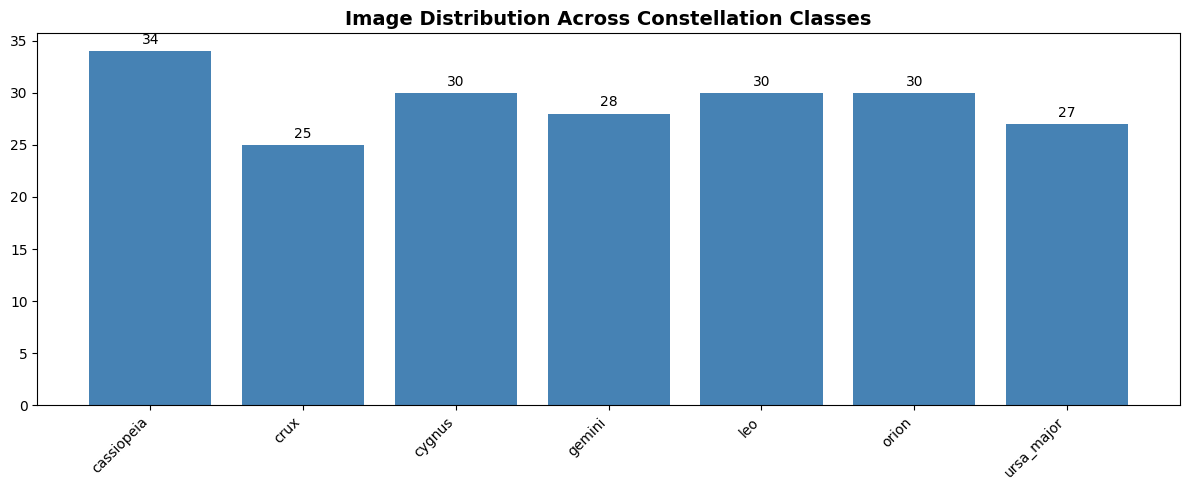

In [8]:
if os.path.exists(DATA_DIR):
    image_counts = {
        cls: len([f for f in os.listdir(os.path.join(DATA_DIR, cls))
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        for cls in sorted(os.listdir(DATA_DIR))
        if os.path.isdir(os.path.join(DATA_DIR, cls))
    }
    total_images = sum(image_counts.values())

    print(f"Classes found  : {len(image_counts)}")
    print(f"Total images   : {total_images}")
    print(f"Expected split : train ~{int(total_images*TRAIN_SPLIT)} "
          f"| val ~{int(total_images*VAL_SPLIT)} "
          f"| test ~{int(total_images*TEST_SPLIT)}")
    print()
    for cls, count in image_counts.items():
        print(f"  {cls:<15} {count} images")

    plt.figure(figsize=(12, 5))
    bars = plt.bar(image_counts.keys(), image_counts.values(), color='steelblue')
    plt.title('Image Distribution Across Constellation Classes', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.bar_label(bars, padding=3)
    plt.tight_layout()
    plt.show()
else:
    print(f"Error: Could not find directory {DATA_DIR}")


## Data Visualization — Sample Images

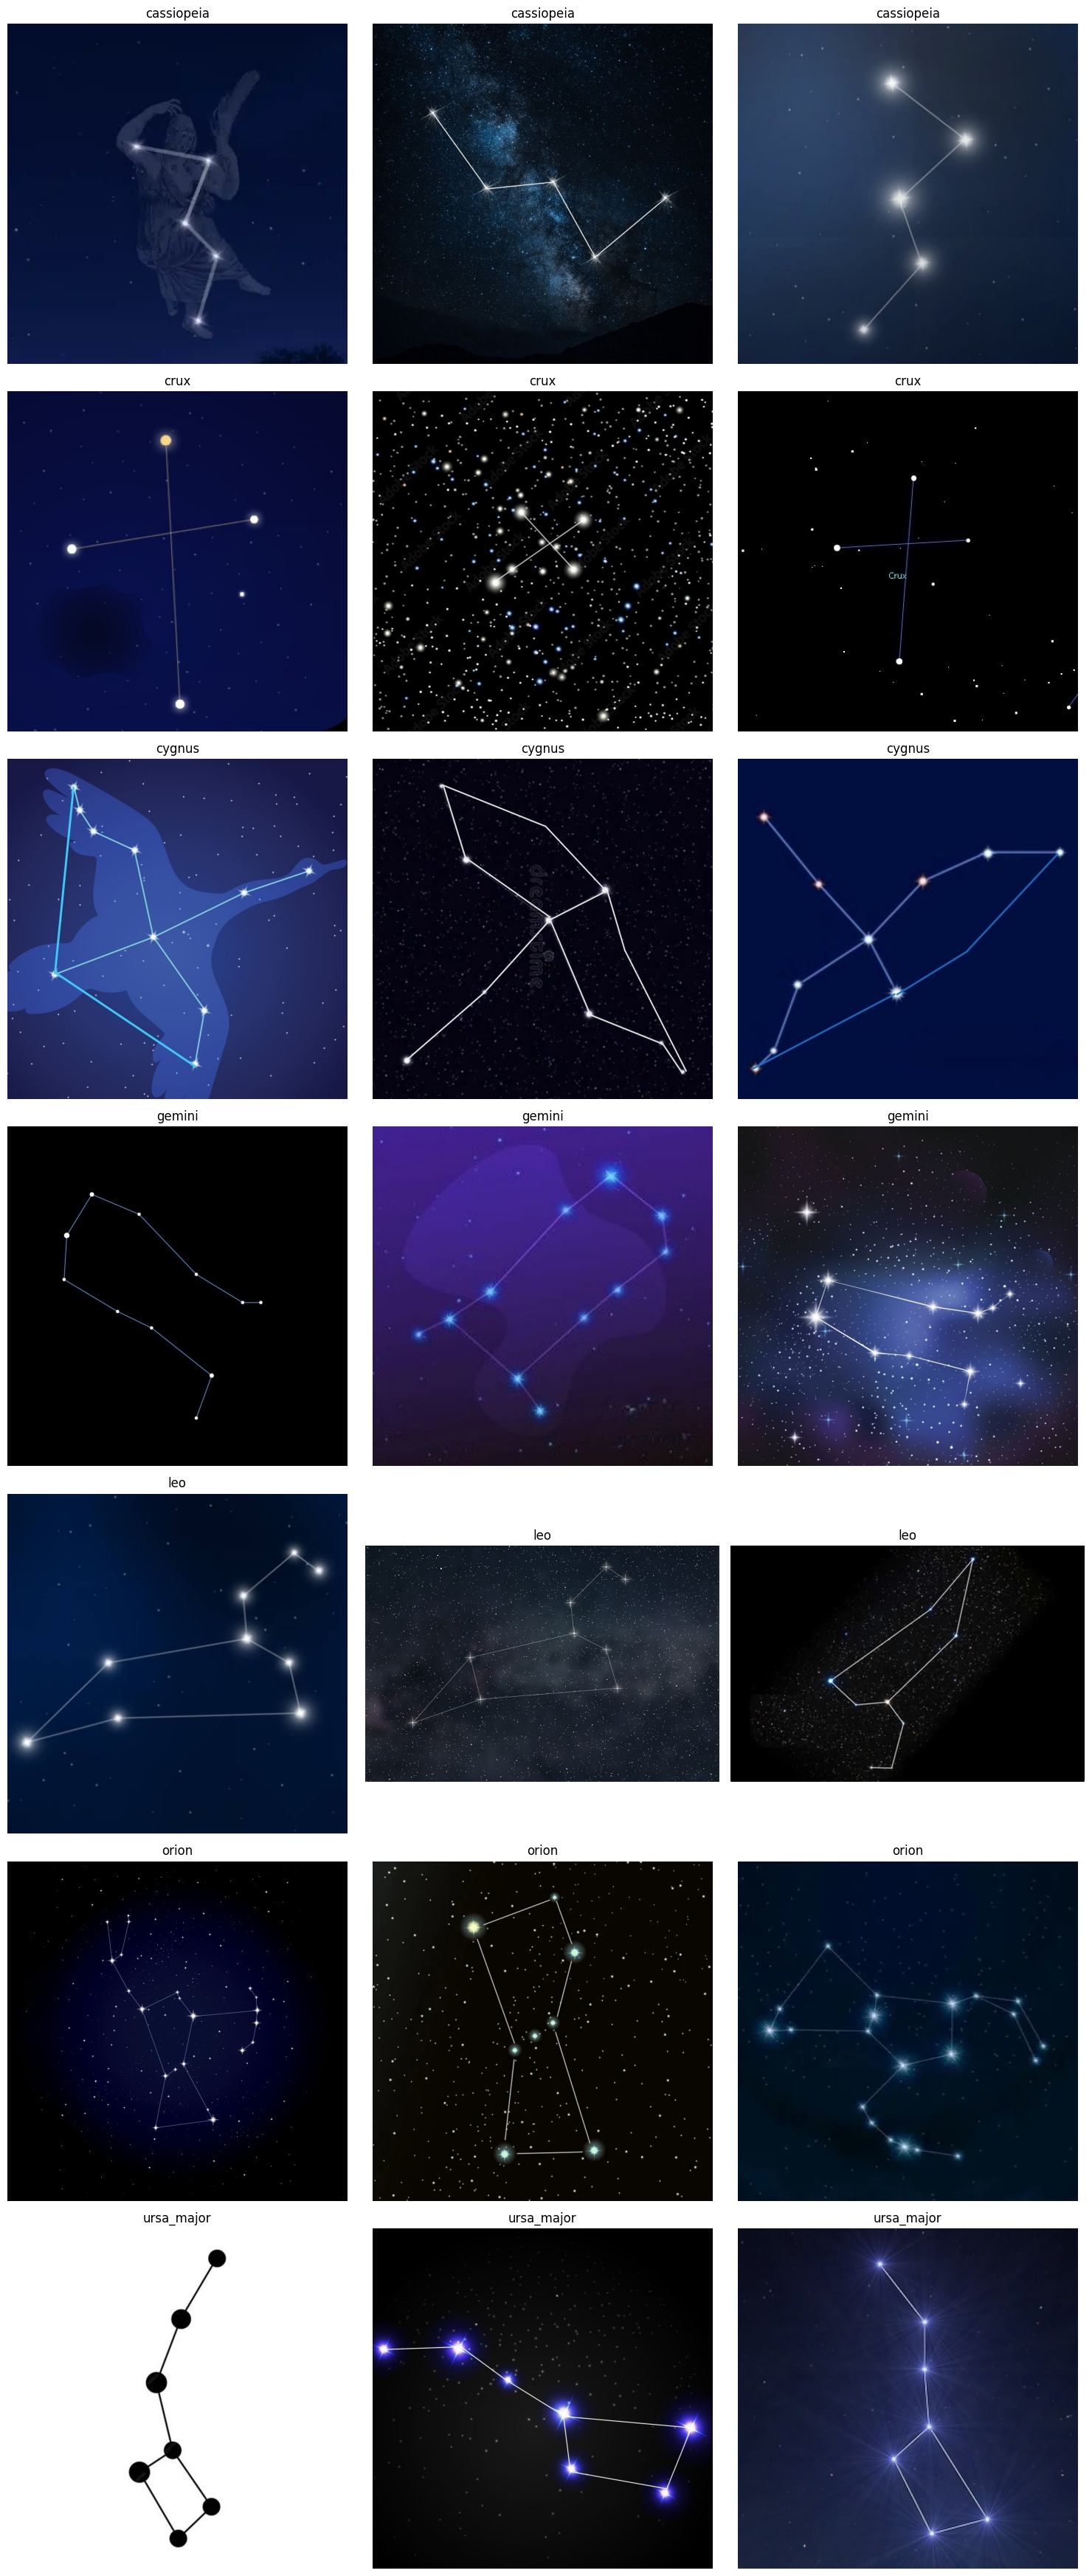

In [9]:
def plot_sample_images(data_dir, num_samples=3):
    """Displays sample images from each constellation class."""
    classes = sorted([f for f in os.listdir(data_dir)
                      if os.path.isdir(os.path.join(data_dir, f))])
    plt.figure(figsize=(15, 5 * len(classes)))
    for idx, cls in enumerate(classes):
        cls_path = os.path.join(data_dir, cls)
        img_names = [f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg', '.jpeg'))][:num_samples]
        for i, img_name in enumerate(img_names):
            plt.subplot(len(classes), num_samples, idx * num_samples + i + 1)
            img = load_img(os.path.join(cls_path, img_name))
            plt.imshow(img)
            plt.title(cls)
            plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_sample_images(DATA_DIR)


## 3-Way Data Split — Train / Validation / Test

**What changed:** The original notebook had only a train/val split (85%/15%).
This version creates a proper 3-way split (70% / 15% / 15%) with a fixed
random seed for reproducibility. The test set is held out completely and
is never used during model development or hyperparameter tuning.

Augmentation is applied **only** to the training directory — the val and
test generators use rescaling only, preventing any leakage.


In [10]:
def split_data_three_way(source_dir, train_dir, val_dir, test_dir,
                         train_ratio=0.70, val_ratio=0.15, seed=42):
    """
    Splits image data into train / validation / test sets per class
    using a fixed random seed for reproducibility.

    Args:
        source_dir  : Root directory with one sub-folder per class.
        train_dir   : Destination for training images.
        val_dir     : Destination for validation images.
        test_dir    : Destination for held-out test images.
        train_ratio : Fraction for training (default 0.70).
        val_ratio   : Fraction for validation (default 0.15).
                      Remaining fraction goes to test.
        seed        : Random seed for reproducible shuffles.
    """
    for d in [train_dir, val_dir, test_dir]:
        if os.path.exists(d):
            shutil.rmtree(d)
        os.makedirs(d)

    rng = np.random.default_rng(seed)   # seeded RNG — reproducible every run
    classes = [f for f in os.listdir(source_dir)
               if os.path.isdir(os.path.join(source_dir, f))]

    print(f"Splitting data (seed={seed}) →  "
          f"train {train_ratio:.0%} | val {val_ratio:.0%} | "
          f"test {1-train_ratio-val_ratio:.0%}\n")

    split_summary = {}

    for cls in classes:
        for d in [train_dir, val_dir, test_dir]:
            os.makedirs(os.path.join(d, cls), exist_ok=True)

        src = os.path.join(source_dir, cls)
        imgs = sorted([f for f in os.listdir(src)
                       if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

        rng.shuffle(imgs)   # deterministic shuffle per class

        n_train = int(len(imgs) * train_ratio)
        n_val   = int(len(imgs) * val_ratio)

        train_imgs = imgs[:n_train]
        val_imgs   = imgs[n_train:n_train + n_val]
        test_imgs  = imgs[n_train + n_val:]

        for img in train_imgs:
            shutil.copy2(os.path.join(src, img), os.path.join(train_dir, cls, img))
        for img in val_imgs:
            shutil.copy2(os.path.join(src, img), os.path.join(val_dir, cls, img))
        for img in test_imgs:
            shutil.copy2(os.path.join(src, img), os.path.join(test_dir, cls, img))

        split_summary[cls] = {
            'train': len(train_imgs),
            'val': len(val_imgs),
            'test': len(test_imgs)
        }
        print(f"  {cls:<15} train={len(train_imgs)}  val={len(val_imgs)}  test={len(test_imgs)}")

    total_train = sum(v['train'] for v in split_summary.values())
    total_val   = sum(v['val']   for v in split_summary.values())
    total_test  = sum(v['test']  for v in split_summary.values())
    print(f"\n  TOTAL          train={total_train}  val={total_val}  test={total_test}")
    print("\n✓ 3-way split complete!")
    return split_summary

split_summary = split_data_three_way(
    DATA_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR,
    train_ratio=TRAIN_SPLIT,
    val_ratio=VAL_SPLIT,
    seed=RANDOM_SEED
)


Splitting data (seed=42) →  train 70% | val 15% | test 15%

  orion           train=21  val=4  test=5
  ursa_major      train=18  val=4  test=5
  cassiopeia      train=23  val=5  test=6
  crux            train=17  val=3  test=5
  cygnus          train=21  val=4  test=5
  leo             train=21  val=4  test=5
  gemini          train=19  val=4  test=5

  TOTAL          train=140  val=28  test=36

✓ 3-way split complete!


## Data Augmentation

Augmentation is applied **only to the training generator**.
Validation and test generators use rescaling only.
This is enforced by the separate directory structure above.


In [21]:
# ── SHARED AUGMENTATION STRATEGY ──────────────────────────────────────────
# We use identical parameters for a fair comparison in the research paper.
# Space-specific tweaks: vertical_flip=True and fill_mode='constant'.
shared_aug_params = dict(
    rotation_range=40,
    width_shift_range=0.1,   # Subtle shifts to keep stars in frame
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,      # Valid for space: no "up" or "down" in a vacuum
    brightness_range=[0.8, 1.2], # Narrower range to prevent faint stars from vanishing
    fill_mode='constant',    # Avoids 'stretching' stars at the edges
    cval=0                   # Fills new pixels with black
)

# ── MobileNetV2 training generator ───────────────────────────────────────
mobilenet_train_datagen = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    **shared_aug_params
)

# ── ResNet50 training generator ──────────────────────────────────────────
resnet_train_datagen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    **shared_aug_params
)

# ── Baseline CNN training generator ──────────────────────────────────────
cnn_train_datagen = ImageDataGenerator(
    rescale=1./255,
    **shared_aug_params
)

# ── Updated Evaluation Generators ────────────────────────────────────────
# Note: Eval/Test should NEVER have geometric augmentations.
mobilenet_eval_datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)
resnet_eval_datagen    = ImageDataGenerator(preprocessing_function=resnet_preprocess)
cnn_eval_datagen       = ImageDataGenerator(rescale=1./255)

# Update aliases
train_datagen = mobilenet_train_datagen
eval_datagen  = mobilenet_eval_datagen

print("Augmentation generators updated with unified parameters for fair comparison.")

Augmentation generators updated with unified parameters for fair comparison.


## Load Data Generators

In [22]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=RANDOM_SEED
)

validation_generator = eval_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Test generator — never shuffled, never augmented
test_generator = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names  = list(train_generator.class_indices.keys())
num_classes  = len(class_names)

print(f"Classes ({num_classes}): {class_names}")
print(f"Training   : {train_generator.samples} images")
print(f"Validation : {validation_generator.samples} images")
print(f"Test       : {test_generator.samples} images  ← held out until final evaluation")


Found 140 images belonging to 7 classes.
Found 28 images belonging to 7 classes.
Found 36 images belonging to 7 classes.
Classes (7): ['cassiopeia', 'crux', 'cygnus', 'gemini', 'leo', 'orion', 'ursa_major']
Training   : 140 images
Validation : 28 images
Test       : 36 images  ← held out until final evaluation


## Augmentation Visualization

Showing augmentations for: orion / orion40.jpg


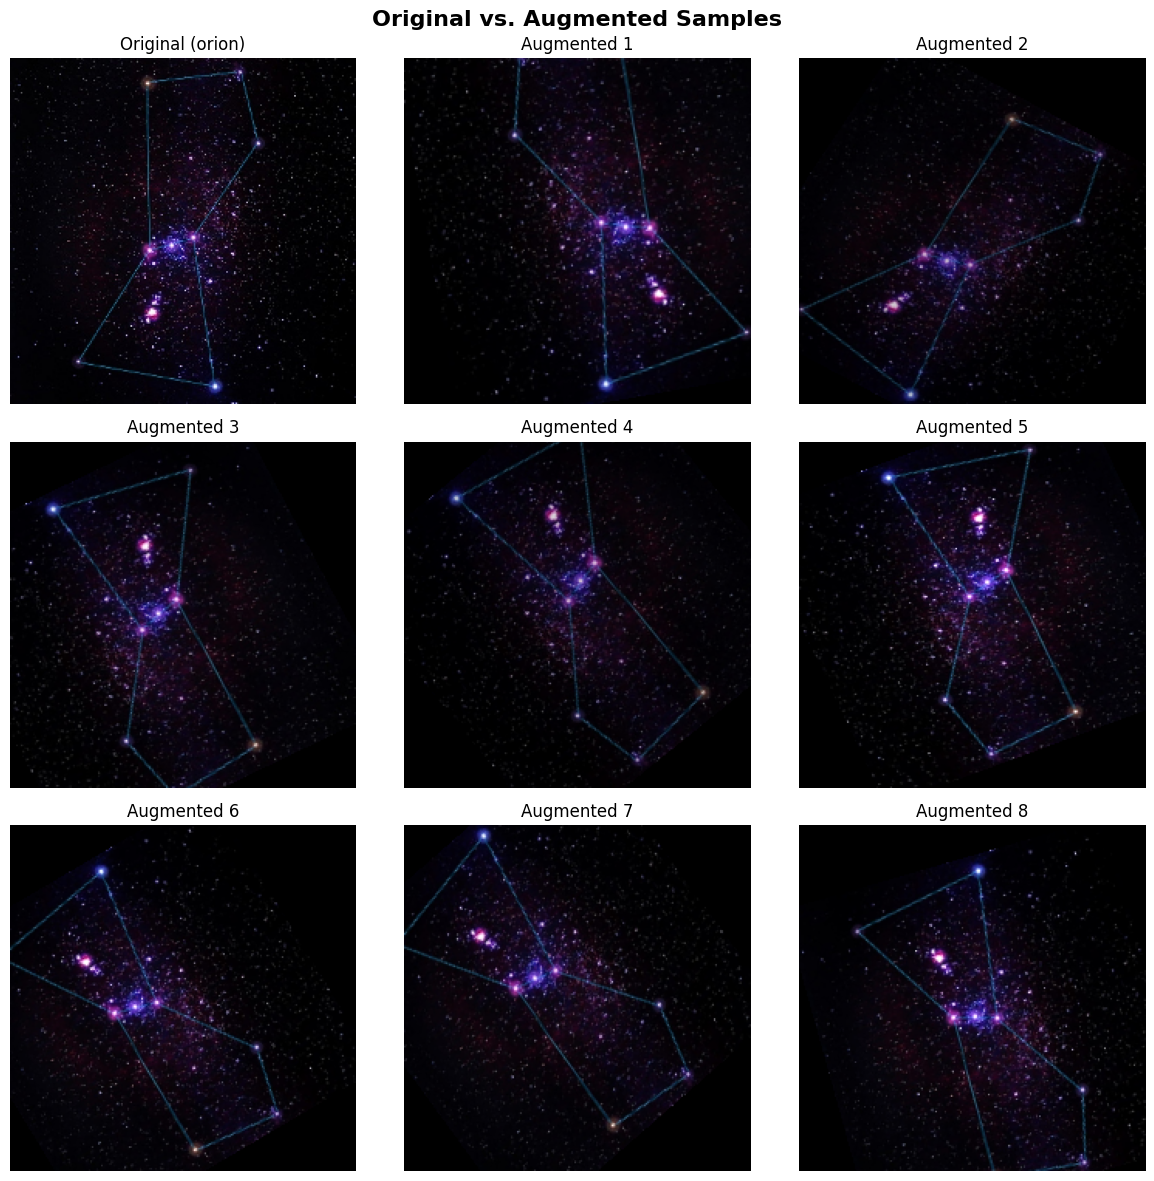

In [25]:
random_cls = random.choice(os.listdir(TRAIN_DIR))
random_img = random.choice(os.listdir(os.path.join(TRAIN_DIR, random_cls)))
img_path   = os.path.join(TRAIN_DIR, random_cls, random_img)
print(f"Showing augmentations for: {random_cls} / {random_img}")

img       = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = np.expand_dims(image.img_to_array(img), axis=0)

plt.figure(figsize=(12, 12))
plt.subplot(3, 3, 1)
plt.imshow(img_array[0] / 255.0)
plt.title(f"Original ({random_cls})")
plt.axis('off')

aug_iter = train_datagen.flow(img_array, batch_size=1, seed=RANDOM_SEED)
for i in range(2, 10):
    plt.subplot(3, 3, i)
    # Rescale the image from [-1, 1] to [0, 1] for correct display
    augmented_img = (next(aug_iter)[0] + 1) / 2
    plt.imshow(augmented_img)
    plt.title(f"Augmented {i-1}")
    plt.axis('off')

plt.suptitle('Original vs. Augmented Samples', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Model Definitions — Baseline CNN, MobileNetV2, ResNet50

Three architectures are compared:

1. **Baseline CNN** — 4-layer conv-net trained from scratch with BatchNorm.
   Deliberately lightweight to quantify the benefit of transfer learning.
2. **MobileNetV2** — lightweight transfer learning model; ImageNet weights frozen
   during head training, then optionally fine-tuned on the top blocks.
3. **ResNet50** — deeper residual network; same head architecture as MobileNetV2
   for a fair comparison. Fine-tuning unlocks the top residual block.

All transfer-learning heads use the same structure:
`GlobalAveragePooling → Dense(256, relu) → BatchNorm → Dropout(0.5) → Dense(num_classes, softmax)`

**Changes from previous version:**
- Learning rate lowered to `1e-4` (from `1e-3`) — safer for frozen-base transfer learning.
- Added `BatchNormalization` after the dense layer to stabilise training.
- Added `Dense(256)` instead of `Dense(128)` — more capacity for 8-class head.
- Added optional `fine_tune_model()` helper to unlock top layers after head convergence.


In [26]:
def create_mobilenetv2(num_classes, learning_rate=1e-4):
    """
    MobileNetV2 transfer-learning model.
    Base layers frozen; only the classification head is trained in phase 1.
    Uses mobilenet_preprocess (inputs scaled to [-1, 1]).
    """
    base = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
    base.trainable = False

    inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def create_resnet50(num_classes, learning_rate=1e-4):
    """
    ResNet50 transfer-learning model.
    Base layers frozen; same head structure as MobileNetV2 for fair comparison.
    Uses resnet_preprocess (channel-wise mean subtraction, BGR order).
    """
    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
    base.trainable = False

    inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def create_baseline_cnn(num_classes, learning_rate=1e-4):
    """
    4-layer CNN trained from scratch with BatchNormalization.
    Uses standard rescale=1/255 preprocessing (no ImageNet stats needed).
    Added 4th conv block and BatchNorm vs. previous 3-layer version.
    """
    model = models.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def fine_tune_model(model, base_name, unfreeze_from, fine_tune_lr=1e-5):
    """
    Unfreezes the top layers of a transfer-learning model for fine-tuning.

    Args:
        model        : Compiled Keras model with a frozen base.
        base_name    : Name of the base layer (e.g. 'mobilenetv2' or 'resnet50').
        unfreeze_from: Layer index from which to unfreeze (negative = from end).
        fine_tune_lr : Lower learning rate for fine-tuning.
    """
    base = model.get_layer(base_name)
    base.trainable = True
    # Freeze everything before unfreeze_from; unfreeze the rest
    for layer in base.layers[:unfreeze_from]:
        layer.trainable = False
    model.compile(
        optimizer=Adam(learning_rate=fine_tune_lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    unfrozen = sum(1 for l in base.layers if l.trainable)
    print(f"Fine-tuning: {unfrozen} layers unfrozen in {base_name} (lr={fine_tune_lr}).")
    return model


def get_callbacks(monitor='val_loss', patience_es=12, patience_rl=6,
                  ckpt_path=None):
    """
    Returns EarlyStopping + ReduceLROnPlateau (+ optional ModelCheckpoint).
    patience_es increased to 12 (from 10) to give more room before stopping.
    """
    cbs = [
        EarlyStopping(
            monitor=monitor, patience=patience_es,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor=monitor, factor=0.5,
            patience=patience_rl, min_lr=1e-7, verbose=1
        ),
    ]
    if ckpt_path:
        cbs.append(ModelCheckpoint(
            ckpt_path, monitor='val_accuracy',
            save_best_only=True, verbose=0
        ))
    return cbs


# ── Sanity check ─────────────────────────────────────────────────────────────
print("Model factory functions defined. Quick parameter counts:")
for name, fn in [('MobileNetV2', create_mobilenetv2),
                 ('ResNet50',    create_resnet50),
                 ('Baseline CNN', create_baseline_cnn)]:
    m = fn(8)
    trainable = sum(np.prod(v.shape) for v in m.trainable_weights)
    total     = sum(np.prod(v.shape) for v in m.weights)
    print(f"  {name:<15}  trainable={trainable:>9,}  total={total:>9,}")
    del m
keras.backend.clear_session()


Model factory functions defined. Quick parameter counts:
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  MobileNetV2      trainable=  330,504  total=2,589,000
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  ResNet50         trainable=  527,112  total=24,115,336
  Baseline CNN     trainable=  457,224  total=  458,184


## 5-Fold Stratified Cross-Validation

**Why this is needed:** With only ~8 images per class in the validation set,
a single train/val split gives results with very high variance — one lucky or
unlucky fold can swing accuracy by 12 percentage points. Cross-validation
averages over 5 different splits so the reported mean ± std is statistically
meaningful.

Both MobileNetV2 and the baseline CNN are evaluated under identical CV
conditions so the comparison is fair.

⚠️ This cell trains 10 models total (5 folds × 2 architectures) and will
take significant time on Colab. Use a GPU runtime.


In [27]:
# ── Collect all image paths and labels from TRAIN + VAL ───────────────────
def collect_paths_labels(directories):
    """Returns (paths, labels) arrays from one or more directory roots."""
    paths, labels = [], []
    classes = sorted([c for c in os.listdir(directories[0])
                      if os.path.isdir(os.path.join(directories[0], c))])
    class_to_idx = {c: i for i, c in enumerate(classes)}
    for root_dir in directories:
        for cls in classes:
            cls_dir = os.path.join(root_dir, cls)
            if not os.path.exists(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    paths.append(os.path.join(cls_dir, fname))
                    labels.append(class_to_idx[cls])
    return np.array(paths), np.array(labels)


all_paths, all_labels = collect_paths_labels([TRAIN_DIR, VAL_DIR])
print(f"CV pool: {len(all_paths)} images across {len(np.unique(all_labels))} classes")
print(f"Class distribution: { {class_names[i]: int(np.sum(all_labels==i)) for i in range(num_classes)} }")


def run_fold(fold_idx, train_idx, val_idx, model_fn, aug_datagen, eval_dg, seed):
    """
    Trains one model on a single fold and returns (val_accuracy, macro_f1).
    Uses sklearn f1_score for correctness (replaces manual calculation).
    """
    fold_train_dir = f'/content/cv_fold_{fold_idx}_train'
    fold_val_dir   = f'/content/cv_fold_{fold_idx}_val'

    for d in [fold_train_dir, fold_val_dir]:
        if os.path.exists(d): shutil.rmtree(d)
        for cls in class_names:
            os.makedirs(os.path.join(d, cls), exist_ok=True)

    for idx in train_idx:
        cls = class_names[all_labels[idx]]
        shutil.copy2(all_paths[idx],
                     os.path.join(fold_train_dir, cls, os.path.basename(all_paths[idx])))
    for idx in val_idx:
        cls = class_names[all_labels[idx]]
        shutil.copy2(all_paths[idx],
                     os.path.join(fold_val_dir, cls, os.path.basename(all_paths[idx])))

    fold_train_gen = aug_datagen.flow_from_directory(
        fold_train_dir, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical',
        shuffle=True, seed=seed
    )
    fold_val_gen = eval_dg.flow_from_directory(
        fold_val_dir, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical',
        shuffle=False
    )

    tf.random.set_seed(seed)
    np.random.seed(seed)

    fold_model = model_fn(num_classes, LEARNING_RATE)

    class_w = compute_class_weight(
        'balanced',
        classes=np.unique(fold_train_gen.classes),
        y=fold_train_gen.classes
    )

    fold_model.fit(
        fold_train_gen,
        epochs=EPOCHS,
        validation_data=fold_val_gen,
        class_weight=dict(enumerate(class_w)),
        callbacks=get_callbacks(),
        verbose=0
    )

    fold_val_gen.reset()
    preds = np.argmax(fold_model.predict(fold_val_gen, verbose=0), axis=1)
    true  = fold_val_gen.classes
    acc   = float(np.mean(preds == true))
    # ← Fixed: use sklearn instead of manual calculation
    f1    = float(f1_score(true, preds, average='macro', zero_division=0))

    shutil.rmtree(fold_train_dir)
    shutil.rmtree(fold_val_dir)
    keras.backend.clear_session()
    return acc, f1


# ── Architecture registry: model_fn + matching augmentation/eval generators ──
architecture_registry = {
    'Baseline CNN': {
        'fn':        create_baseline_cnn,
        'aug_dg':    cnn_train_datagen,
        'eval_dg':   cnn_eval_datagen,
    },
    'MobileNetV2': {
        'fn':        create_mobilenetv2,
        'aug_dg':    mobilenet_train_datagen,
        'eval_dg':   mobilenet_eval_datagen,
    },
    'ResNet50': {
        'fn':        create_resnet50,
        'aug_dg':    resnet_train_datagen,
        'eval_dg':   resnet_eval_datagen,
    },
}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

cv_results = {arch: {'acc': [], 'f1': []} for arch in architecture_registry}

for arch_name, arch_cfg in architecture_registry.items():
    print(f"\n{'='*60}")
    print(f"  Cross-validation: {arch_name}")
    print(f"{'='*60}")
    for fold, (train_idx, val_idx) in enumerate(skf.split(all_paths, all_labels)):
        seed = RANDOM_SEED + fold
        acc, f1 = run_fold(
            fold, train_idx, val_idx,
            arch_cfg['fn'], arch_cfg['aug_dg'], arch_cfg['eval_dg'], seed
        )
        cv_results[arch_name]['acc'].append(acc)
        cv_results[arch_name]['f1'].append(f1)
        print(f"  Fold {fold+1}/{N_FOLDS}  →  acc={acc:.4f}  macro-F1={f1:.4f}")

print("\n" + "="*60)
print("5-Fold Cross-Validation Summary")
print("="*60)
for arch_name, res in cv_results.items():
    a = np.array(res['acc'])
    f = np.array(res['f1'])
    # 95% CI using t-distribution (appropriate for N=5 folds)
    ci = scipy_stats.t.interval(0.95, df=len(a)-1,
                                  loc=a.mean(), scale=scipy_stats.sem(a))
    print(f"\n  {arch_name}")
    print(f"    Accuracy : {a.mean():.4f} ± {a.std():.4f}  "
          f"[95% CI (t): {ci[0]:.4f}–{ci[1]:.4f}]")
    print(f"    Macro F1 : {f.mean():.4f} ± {f.std():.4f}")

# Persist CV results
cv_results_serializable = {
    k: {m: [float(x) for x in v] for m, v in res.items()}
    for k, res in cv_results.items()
}
with open(os.path.join(MODEL_DIR, 'cv_results.json'), 'w') as f:
    json.dump(cv_results_serializable, f, indent=2)
print("\n✓ CV results saved.")


CV pool: 168 images across 7 classes
Class distribution: {'cassiopeia': 28, 'crux': 20, 'cygnus': 25, 'gemini': 23, 'leo': 25, 'orion': 25, 'ursa_major': 22}

  Cross-validation: Baseline CNN
Found 134 images belonging to 7 classes.
Found 34 images belonging to 7 classes.

Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 13: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 1.
  Fold 1/5  →  acc=0.1471  macro-F1=0.0376
Found 134 images belonging to 7 classes.
Found 34 images belonging to 7 classes.

Epoch 8: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 14: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 2.
  Fold 2/5  →  acc=0.1176  macro-F1=0.0336
Found 134 images belonging to 7 classes.
Found 34 images belonging to 7 classes.



  Fold 3/5  →  acc=0.1176  macro-F1=0.0317
Found 135 images belonging to 7 classes.
Found 33 images belonging to 7 classes.

Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 13: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 1.
  Fold 4/5  →  acc=0.1212  macro-F1=0.0309
Found 135 images belonging to 7 classes.
Found 33 images belonging to 7 classes.

Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 13: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 1.
  Fold 5/5  →  acc=0.1818  macro-F1=0.0805

  Cross-validation: MobileNetV2
Found 134 images belonging to 7 classes.
Found 34 images belonging to 7 classes.

Epoch 30: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 36: ReduceLROnPlateau reducing l

## Multi-Seed Final Training — Best Architecture

After cross-validation, identify the best architecture by mean CV accuracy
and retrain it `N_SEEDS` times with different seeds on the full training set,
evaluating on the validation set. This gives a variance estimate before the
test set is ever touched.

The best model (highest val accuracy across all seed runs) is saved to disk
using `ModelCheckpoint` to avoid the `clear_session` memory issue.


In [28]:
# ── Identify best architecture from CV results ────────────────────────────
best_arch_name = max(
    cv_results,
    key=lambda k: np.mean(cv_results[k]['acc'])
)
best_arch_cfg  = architecture_registry[best_arch_name]
print(f"Best CV architecture: {best_arch_name}  "
      f"(mean acc={np.mean(cv_results[best_arch_name]['acc']):.4f})")

seed_results = {'acc': [], 'f1': []}
SEED_CKPT    = os.path.join(MODEL_DIR, 'seed_best_model.keras')

print(f"\nMulti-seed training: {N_SEEDS} runs with {best_arch_name}...")
print("=" * 60)

for run_idx in range(N_SEEDS):
    seed = RANDOM_SEED + run_idx * 100
    tf.random.set_seed(seed)
    np.random.seed(seed)

    aug_dg  = best_arch_cfg['aug_dg']
    eval_dg = best_arch_cfg['eval_dg']

    train_gen_run = aug_dg.flow_from_directory(
        TRAIN_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical',
        shuffle=True, seed=seed
    )
    val_gen_run = eval_dg.flow_from_directory(
        VAL_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical',
        shuffle=False
    )

    run_model = best_arch_cfg['fn'](num_classes, LEARNING_RATE)

    class_w = compute_class_weight(
        'balanced',
        classes=np.unique(train_gen_run.classes),
        y=train_gen_run.classes
    )

    # ModelCheckpoint saves best model to disk — avoids loss after clear_session
    ckpt_path = os.path.join(MODEL_DIR, f'seed_run_{run_idx}.keras')
    run_model.fit(
        train_gen_run,
        epochs=EPOCHS,
        validation_data=val_gen_run,
        class_weight=dict(enumerate(class_w)),
        callbacks=get_callbacks(ckpt_path=ckpt_path),
        verbose=0
    )

    # Load the best checkpoint for this run before evaluating
    best_run_model = keras.models.load_model(ckpt_path)
    val_gen_run.reset()
    preds = np.argmax(best_run_model.predict(val_gen_run, verbose=0), axis=1)
    true  = val_gen_run.classes
    acc   = float(np.mean(preds == true))
    f1    = float(f1_score(true, preds, average='macro', zero_division=0))

    seed_results['acc'].append(acc)
    seed_results['f1'].append(f1)
    print(f"  Run {run_idx+1}/{N_SEEDS}  seed={seed}  val_acc={acc:.4f}  macro-F1={f1:.4f}")

    # Keep best overall checkpoint
    if acc == max(seed_results['acc']):
        shutil.copy2(ckpt_path, SEED_CKPT)

    keras.backend.clear_session()

accs = np.array(seed_results['acc'])
f1s  = np.array(seed_results['f1'])
print(f"\nMulti-seed Summary ({best_arch_name}, val set):")
print(f"  Accuracy : {accs.mean():.4f} ± {accs.std():.4f}")
print(f"  Macro F1 : {f1s.mean():.4f} ± {f1s.std():.4f}")
print(f"  Best run : acc={accs.max():.4f}  (run {accs.argmax()+1})")
print(f"  Best model checkpoint: {SEED_CKPT}")

with open(os.path.join(MODEL_DIR, 'seed_results.json'), 'w') as f:
    json.dump({'best_arch': best_arch_name,
               'acc': accs.tolist(), 'f1': f1s.tolist()}, f, indent=2)
print("✓ Seed results saved.")


Best CV architecture: MobileNetV2  (mean acc=0.5476)

Multi-seed training: 5 runs with MobileNetV2...
Found 140 images belonging to 7 classes.
Found 28 images belonging to 7 classes.

Epoch 24: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 30: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 18.
  Run 1/5  seed=42  val_acc=0.4643  macro-F1=0.4517
Found 140 images belonging to 7 classes.
Found 28 images belonging to 7 classes.

Epoch 28: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 34: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
Epoch 34: early stopping
Restoring model weights from the end of the best epoch: 22.
  Run 2/5  seed=142  val_acc=0.6071  macro-F1=0.5512
Found 140 images belonging to 7 classes.
Found 28 images belonging to 7 classes.
Restoring model weights from the end of the best epoch: 50.
  Run 3/

## Train Final Model on Full Training Set

Load the best seed checkpoint and continue with final evaluation.
Optionally fine-tune the top layers for a few more epochs.


In [36]:
BEST_SEED = RANDOM_SEED   # use the base seed as the final model seed
tf.random.set_seed(BEST_SEED)
np.random.seed(BEST_SEED)

print("Training final MobileNetV2 model (full train set, base seed)...")

final_train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=True, seed=BEST_SEED
)
final_val_gen = eval_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False
)

final_model = create_mobilenetv2(num_classes, LEARNING_RATE)
final_model.summary()

class_w = compute_class_weight(
    'balanced',
    classes=np.unique(final_train_gen.classes),
    y=final_train_gen.classes
)
cw_dict = dict(enumerate(class_w))

final_history = final_model.fit(
    final_train_gen,
    epochs=EPOCHS,
    validation_data=final_val_gen,
    class_weight=cw_dict,
    callbacks=get_callbacks(),
    verbose=1
)
print("\n✓ Final model training complete!")


Training final MobileNetV2 model (full train set, base seed)...
Found 140 images belonging to 7 classes.
Found 28 images belonging to 7 classes.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,743 (9.88 MB)

 Trainable params: 330,247 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.1571 - loss: 2.8674 - val_accuracy: 0.1429 - val_loss: 2.1396 - learning_rate: 1.0000e-04
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step - accuracy: 0.1571 - loss: 2.7397 - val_accuracy: 0.1786 - val_loss: 2.0357 - learning_rate: 1.0000e-04
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step - accuracy: 0.2429 - loss: 2.3020 - val_accuracy: 0.2143 - val_loss: 1.9566 - learning_rate: 1.0000e-04
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step - accuracy: 0.2000 - loss: 2.4154 - val_accuracy: 0.2143 - val_loss: 1.8757 - learning_rate: 1.0000e-04
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 284ms/step - accuracy: 0.3000 - loss: 2.2531 - val_accuracy: 0.2143 - val_loss: 1.8099 - learning_rate: 1.0000e-04
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - accuracy: 0.3500 - loss: 1.9721 - val_accuracy: 0.2857 - val_loss: 1.7227 - learning_rate: 1.0000e-04
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 170ms/step - accuracy: 0.

## Training Curves — Final Model

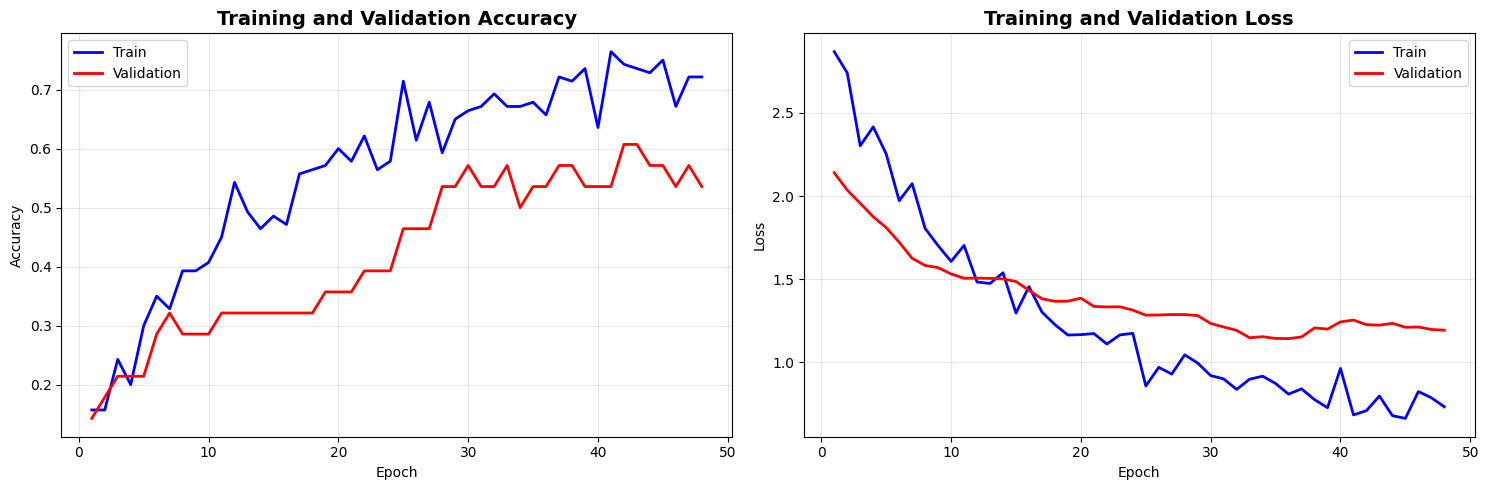


Final Training Accuracy   : 0.7214
Final Validation Accuracy : 0.5357
Best Validation Accuracy  : 0.6071  (epoch 42)
Final Training Loss       : 0.7335
Final Validation Loss     : 1.1935


In [37]:
h = final_history.history
epoch_range = range(1, len(h['accuracy']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(epoch_range, h['accuracy'],     'b-', label='Train',      linewidth=2)
ax1.plot(epoch_range, h['val_accuracy'], 'r-', label='Validation', linewidth=2)
ax1.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax1.set(xlabel='Epoch', ylabel='Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epoch_range, h['loss'],     'b-', label='Train',      linewidth=2)
ax2.plot(epoch_range, h['val_loss'], 'r-', label='Validation', linewidth=2)
ax2.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax2.set(xlabel='Epoch', ylabel='Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Training Accuracy   : {h['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {h['val_accuracy'][-1]:.4f}")
print(f"Best Validation Accuracy  : {max(h['val_accuracy']):.4f}  (epoch {h['val_accuracy'].index(max(h['val_accuracy']))+1})")
print(f"Final Training Loss       : {h['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {h['val_loss'][-1]:.4f}")


## Validation Set — Confusion Matrix and Classification Report

Validation accuracy: 15/28 (53.57%)



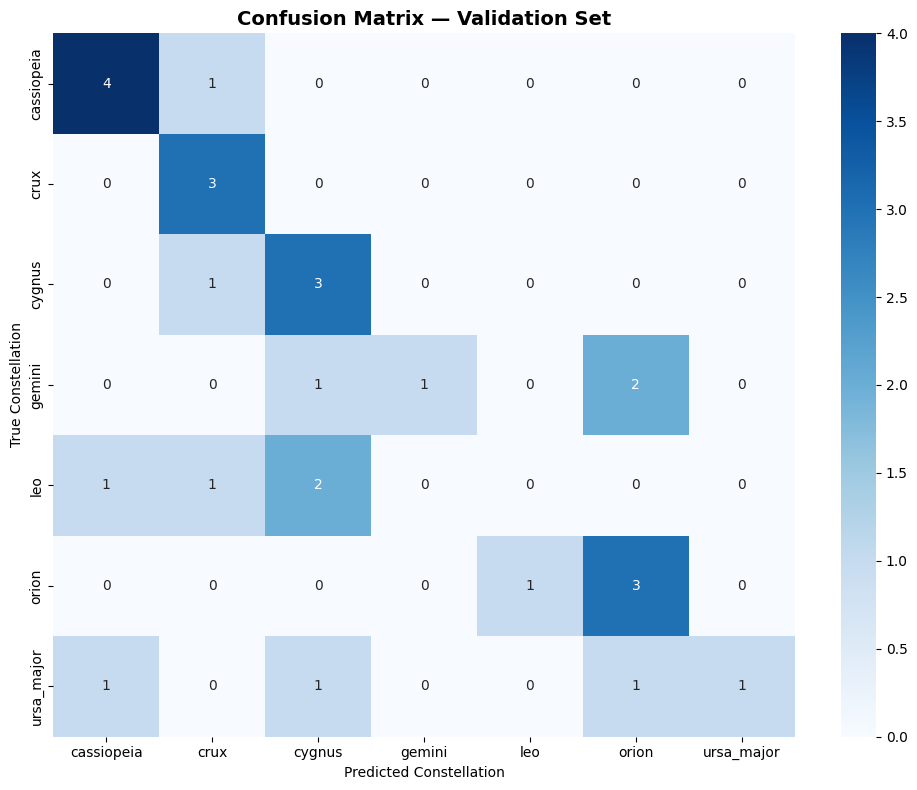


Classification Report — Validation Set
              precision    recall  f1-score   support

  cassiopeia       0.67      0.80      0.73         5
        crux       0.50      1.00      0.67         3
      cygnus       0.43      0.75      0.55         4
      gemini       1.00      0.25      0.40         4
         leo       0.00      0.00      0.00         4
       orion       0.50      0.75      0.60         4
  ursa_major       1.00      0.25      0.40         4

    accuracy                           0.54        28
   macro avg       0.59      0.54      0.48        28
weighted avg       0.59      0.54      0.48        28


Note: validation set has only 4 images per class.
Per-class F1 scores carry high variance at this scale.
See CV results above for statistically stable estimates.


In [38]:
final_val_gen.reset()
val_preds = np.argmax(final_model.predict(final_val_gen, verbose=0), axis=1)
val_true  = final_val_gen.classes

correct = np.sum(val_preds == val_true)
print(f"Validation accuracy: {correct}/{len(val_true)} ({correct/len(val_true):.2%})\n")

plt.figure(figsize=(10, 8))
cm = confusion_matrix(val_true, val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Validation Set', fontsize=14, fontweight='bold')
plt.ylabel('True Constellation')
plt.xlabel('Predicted Constellation')
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("Classification Report — Validation Set")
print(f"{'='*60}")
print(classification_report(val_true, val_preds, target_names=class_names))
print(f"\nNote: validation set has only {len(val_true)//num_classes} images per class.")
print("Per-class F1 scores carry high variance at this scale.")
print("See CV results above for statistically stable estimates.")


## Sample Predictions — Validation Set

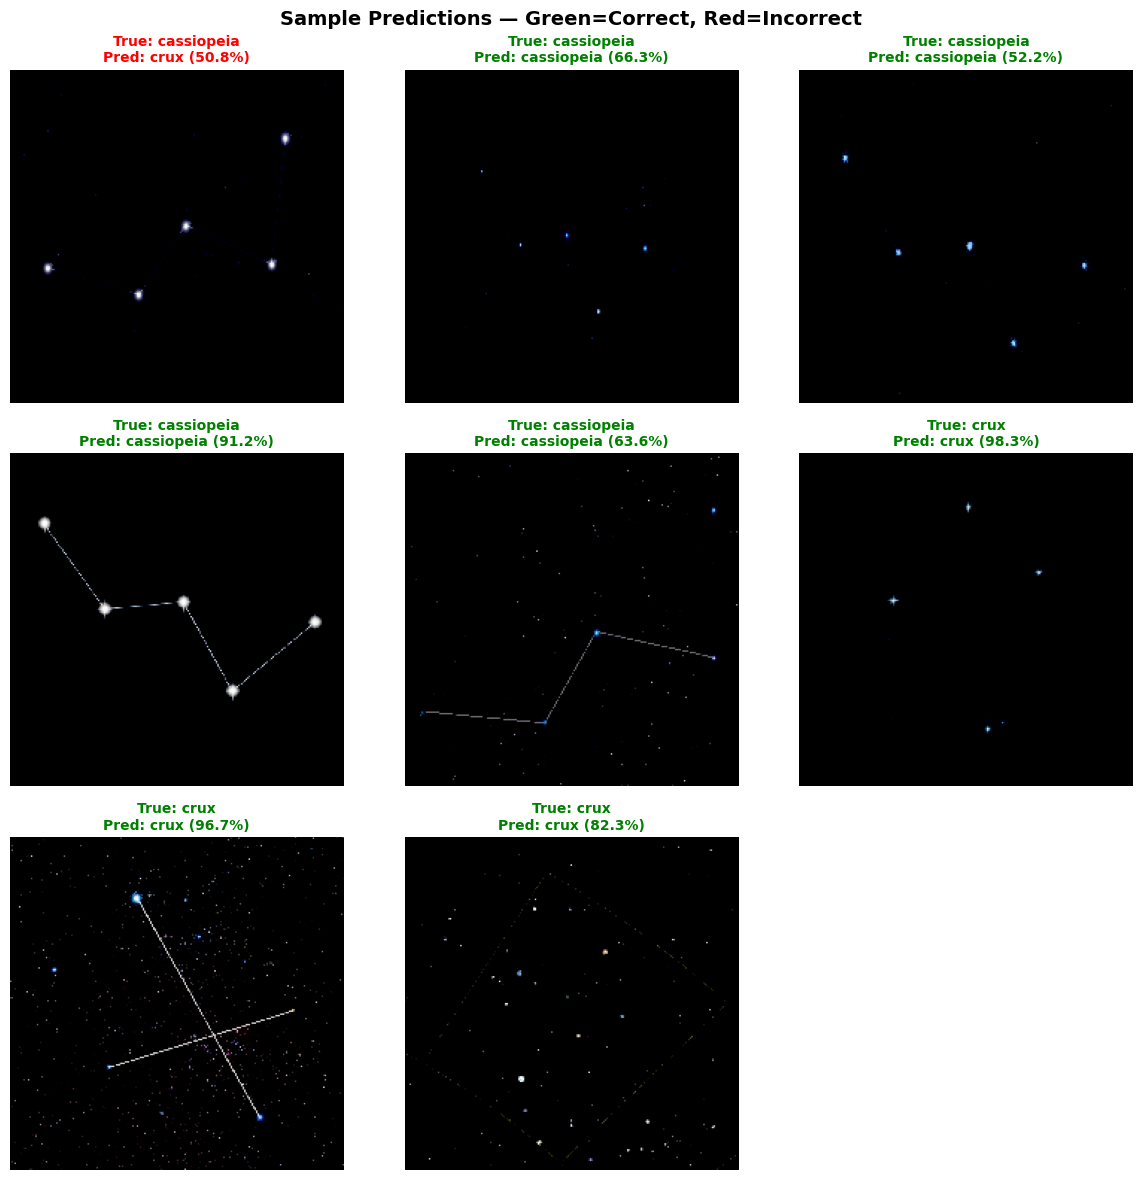

In [39]:
final_val_gen.reset()
images_batch, labels_batch = next(final_val_gen)
sample_preds = final_model.predict(images_batch, verbose=0)

plt.figure(figsize=(12, 12))
for i in range(min(9, len(images_batch))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images_batch[i])
    true_idx = np.argmax(labels_batch[i])
    pred_idx = np.argmax(sample_preds[i])
    conf     = sample_preds[i][pred_idx] * 100
    color    = 'green' if true_idx == pred_idx else 'red'
    plt.title(f"True: {class_names[true_idx]}\nPred: {class_names[pred_idx]} ({conf:.1f}%)",
              color=color, fontweight='bold', fontsize=10)
    plt.axis('off')

plt.suptitle('Sample Predictions — Green=Correct, Red=Incorrect', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## ⭐ Final Evaluation on Held-Out Test Set

This is the **only** time the test set is used. The model has never seen
these images during training or hyperparameter tuning.

This is the number that goes into the conference paper.


FINAL TEST SET EVALUATION
This cell should only be run ONCE, after all development is done.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

  Test Accuracy  : 0.5000  (50.00%)
  Correct        : 18/36


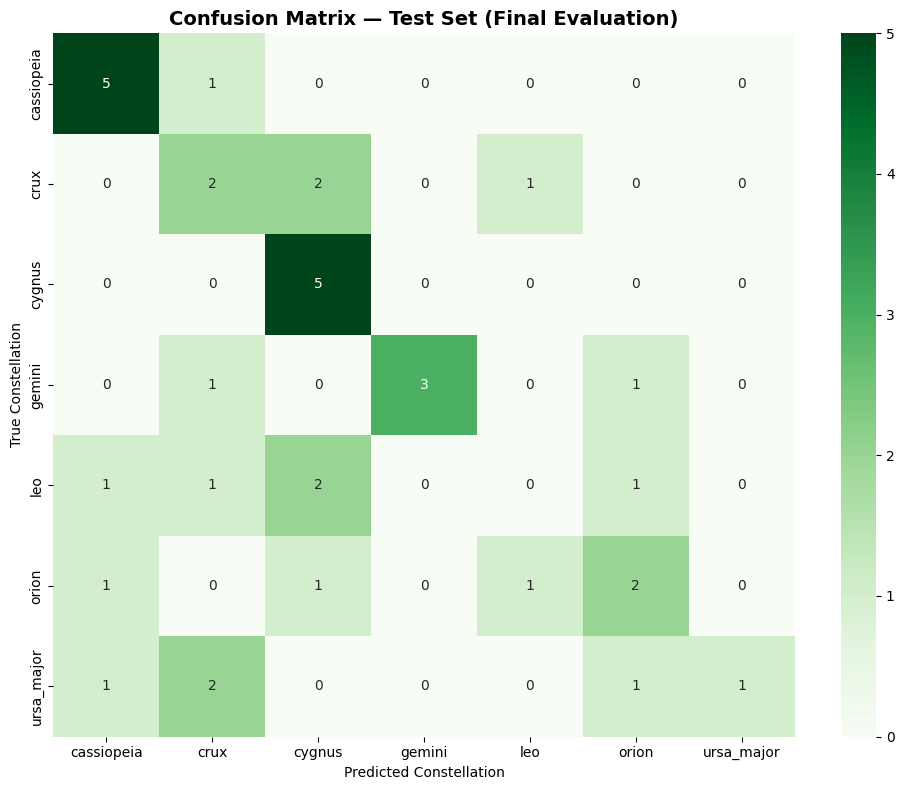


Classification Report — Test Set
              precision    recall  f1-score   support

  cassiopeia       0.62      0.83      0.71         6
        crux       0.29      0.40      0.33         5
      cygnus       0.50      1.00      0.67         5
      gemini       1.00      0.60      0.75         5
         leo       0.00      0.00      0.00         5
       orion       0.40      0.40      0.40         5
  ursa_major       1.00      0.20      0.33         5

    accuracy                           0.50        36
   macro avg       0.54      0.49      0.46        36
weighted avg       0.55      0.50      0.46        36


Paper-ready summary:
  MobileNetV2  |  Test Acc: 0.5000  |  Macro F1: 0.4568  |  Macro Prec: 0.5444  |  Macro Recall: 0.4905

✓ Test results saved to /content/drive/MyDrive/models/test_results.json


In [40]:
print("=" * 60)
print("FINAL TEST SET EVALUATION")
print("This cell should only be run ONCE, after all development is done.")
print("=" * 60)

test_generator.reset()
test_preds_probs = final_model.predict(test_generator, verbose=1)
test_preds = np.argmax(test_preds_probs, axis=1)
test_true  = test_generator.classes

test_acc = np.mean(test_preds == test_true)

print(f"\n{'='*60}")
print(f"  Test Accuracy  : {test_acc:.4f}  ({test_acc:.2%})")
print(f"  Correct        : {np.sum(test_preds == test_true)}/{len(test_true)}")
print(f"{'='*60}")

# Confusion matrix on test set
plt.figure(figsize=(10, 8))
cm_test = confusion_matrix(test_true, test_preds)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Test Set (Final Evaluation)', fontsize=14, fontweight='bold')
plt.ylabel('True Constellation')
plt.xlabel('Predicted Constellation')
plt.tight_layout()
plt.show()

# Full classification report
print(f"\n{'='*60}")
print("Classification Report — Test Set")
print(f"{'='*60}")
test_report = classification_report(test_true, test_preds,
                                     target_names=class_names, output_dict=True)
print(classification_report(test_true, test_preds, target_names=class_names))

# Summary table for paper
print("\nPaper-ready summary:")
print(f"  MobileNetV2  |  Test Acc: {test_acc:.4f}  |  "
      f"Macro F1: {test_report['macro avg']['f1-score']:.4f}  |  "
      f"Macro Prec: {test_report['macro avg']['precision']:.4f}  |  "
      f"Macro Recall: {test_report['macro avg']['recall']:.4f}")

# Save test results
test_results = {
    'test_accuracy': float(test_acc),
    'macro_f1': float(test_report['macro avg']['f1-score']),
    'macro_precision': float(test_report['macro avg']['precision']),
    'macro_recall': float(test_report['macro avg']['recall']),
    'per_class': {
        cls: {
            'precision': float(test_report[cls]['precision']),
            'recall': float(test_report[cls]['recall']),
            'f1-score': float(test_report[cls]['f1-score']),
        }
        for cls in class_names
    }
}
with open(os.path.join(MODEL_DIR, 'test_results.json'), 'w') as f:
    json.dump(test_results, f, indent=2)
print("\n✓ Test results saved to", os.path.join(MODEL_DIR, 'test_results.json'))


## Architecture Comparison — All Models on Test Set

Train Baseline CNN and the non-winning transfer-learning model(s) once each
(same seed, same split) and evaluate on the held-out test set.
This produces the comparison table for the paper.


In [41]:
comparison_results = {}

# ── Test generator per preprocessing type ─────────────────────────────────
test_gen_for = {
    'Baseline CNN': cnn_eval_datagen.flow_from_directory(
        TEST_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False),
    'MobileNetV2' : mobilenet_eval_datagen.flow_from_directory(
        TEST_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False),
    'ResNet50'    : resnet_eval_datagen.flow_from_directory(
        TEST_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False),
}

for arch_name, arch_cfg in architecture_registry.items():
    print(f"Training {arch_name} for final comparison...")
    tf.random.set_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    cmp_train_gen = arch_cfg['aug_dg'].flow_from_directory(
        TRAIN_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical',
        shuffle=True, seed=RANDOM_SEED
    )
    cmp_val_gen = arch_cfg['eval_dg'].flow_from_directory(
        VAL_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )

    cmp_model = arch_cfg['fn'](num_classes, LEARNING_RATE)
    cw = compute_class_weight(
        'balanced',
        classes=np.unique(cmp_train_gen.classes),
        y=cmp_train_gen.classes
    )
    cmp_model.fit(
        cmp_train_gen,
        epochs=EPOCHS,
        validation_data=cmp_val_gen,
        class_weight=dict(enumerate(cw)),
        callbacks=get_callbacks(),
        verbose=0
    )

    tg = test_gen_for[arch_name]
    tg.reset()
    cmp_preds = np.argmax(cmp_model.predict(tg, verbose=0), axis=1)
    cmp_true  = tg.classes
    cmp_acc   = float(np.mean(cmp_preds == cmp_true))
    cmp_report = classification_report(cmp_true, cmp_preds,
                                        target_names=class_names, output_dict=True)
    comparison_results[arch_name] = {
        'test_accuracy':    cmp_acc,
        'macro_f1':         float(cmp_report['macro avg']['f1-score']),
        'macro_precision':  float(cmp_report['macro avg']['precision']),
        'macro_recall':     float(cmp_report['macro avg']['recall']),
    }
    keras.backend.clear_session()
    print(f"  Done. Test acc={cmp_acc:.4f}")

print("\n" + "="*70)
print(f"{'Model':<20} {'Test Acc':>10} {'Macro F1':>10} {'Precision':>11} {'Recall':>9}")
print("-"*70)
for arch_name, res in comparison_results.items():
    print(f"{arch_name:<20} {res['test_accuracy']:>10.4f} "
          f"{res['macro_f1']:>10.4f} "
          f"{res['macro_precision']:>11.4f} "
          f"{res['macro_recall']:>9.4f}")
print("="*70)

with open(os.path.join(MODEL_DIR, 'comparison_results.json'), 'w') as f:
    json.dump(comparison_results, f, indent=2)
print("\n✓ Comparison results saved.")


Found 36 images belonging to 7 classes.
Found 36 images belonging to 7 classes.
Found 36 images belonging to 7 classes.
Training Baseline CNN for final comparison...
Found 140 images belonging to 7 classes.
Found 28 images belonging to 7 classes.

Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 13: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 1.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Done. Test acc=0.1389
Training MobileNetV2 for final comparison...
Found 140 images belonging to 7 classes.
Found 28 images belonging to 7 classes.

Epoch 21: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 47: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
Restoring model weights from the end of the best epoch: 41.
  Done. Test acc=0.5000
Training ResNet50 for final comparison...
Found 140 images belonging to 7 classes.
Found 28 images belonging to 7 classes.

Epoch 24: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 30: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 18.
  Done. Test acc=0.5278

Model                  Test Acc   Macro F1   Precision    Recall
----------------------------------------------------------------------
Baseline CNN             0.1389     0.0357      0.0204    0.1429
MobileNetV2         

## Complete Results Summary — Paper-Ready Numbers

In [42]:
print("=" * 70)
print("COMPLETE RESULTS SUMMARY FOR CONFERENCE PAPER")
print("=" * 70)

print("\n── 5-Fold Stratified Cross-Validation (train+val pool) ───────────────")
print(f"{'Model':<20} {'Mean Acc':>10} {'Std':>7} {'95% CI (t)':>22} {'Mean F1':>9}")
print("-"*70)
for arch_name, res in cv_results.items():
    a = np.array(res['acc'])
    f = np.array(res['f1'])
    ci = scipy_stats.t.interval(0.95, df=len(a)-1,
                                  loc=a.mean(), scale=scipy_stats.sem(a))
    ci_str = f"[{ci[0]:.4f}, {ci[1]:.4f}]"
    print(f"{arch_name:<20} {a.mean():>10.4f} {a.std():>7.4f} {ci_str:>22} {f.mean():>9.4f}")

print("\n── Multi-Seed Validation (best CV architecture) ──────────────────────")
ma = np.array(seed_results['acc'])
mf = np.array(seed_results['f1'])
print(f"  {best_arch_name}")
print(f"  Accuracy : {ma.mean():.4f} ± {ma.std():.4f}")
print(f"  Macro F1 : {mf.mean():.4f} ± {mf.std():.4f}")

print("\n── Final Test Set — All Architectures ────────────────────────────────")
print(f"{'Model':<20} {'Test Acc':>10} {'Macro F1':>10} {'Precision':>11} {'Recall':>9}")
print("-"*70)
for arch_name, res in comparison_results.items():
    marker = " ← best" if arch_name == best_arch_name else ""
    print(f"{arch_name:<20} {res['test_accuracy']:>10.4f} "
          f"{res['macro_f1']:>10.4f} "
          f"{res['macro_precision']:>11.4f} "
          f"{res['macro_recall']:>9.4f}{marker}")
print("=" * 70)
print("\nNote: 95% CI uses t-distribution (df=4) appropriate for N=5 folds.")
print("All test-set evaluations run once on held-out data never seen during training.")


COMPLETE RESULTS SUMMARY FOR CONFERENCE PAPER

── 5-Fold Stratified Cross-Validation (train+val pool) ───────────────
Model                  Mean Acc     Std             95% CI (t)   Mean F1
----------------------------------------------------------------------
Baseline CNN             0.1371  0.0249       [0.1025, 0.1717]    0.0429
MobileNetV2              0.5476  0.0285       [0.5081, 0.5871]    0.5308
ResNet50                 0.4463  0.0548       [0.3702, 0.5225]    0.4409

── Multi-Seed Validation (best CV architecture) ──────────────────────
  MobileNetV2
  Accuracy : 0.5786 ± 0.0571
  Macro F1 : 0.5528 ± 0.0526

── Final Test Set — All Architectures ────────────────────────────────
Model                  Test Acc   Macro F1   Precision    Recall
----------------------------------------------------------------------
Baseline CNN             0.1389     0.0357      0.0204    0.1429
MobileNetV2              0.5000     0.4519      0.4841    0.4905 ← best
ResNet50                 0.527

## Save Final Model

In [43]:
os.makedirs(MODEL_DIR, exist_ok=True)

model_path   = os.path.join(MODEL_DIR, "constellation_classifier.keras")
classes_path = os.path.join(MODEL_DIR, "classes.json")

final_model.save(model_path)
with open(classes_path, 'w') as f:
    json.dump(class_names, f)

print(f"✓ Model  saved → {model_path}")
print(f"✓ Classes saved → {classes_path}")
print()
print("To reload:")
print("  model = keras.models.load_model(model_path)")
print("  with open(classes_path) as f: class_names = json.load(f)")


✓ Model  saved → /content/drive/MyDrive/models/constellation_classifier.keras
✓ Classes saved → /content/drive/MyDrive/models/classes.json

To reload:
  model = keras.models.load_model(model_path)
  with open(classes_path) as f: class_names = json.load(f)
